# Corruption Robustness Evaluation

Evaluates the fine-tuned model's test accuracy on clean CIFAR-10 and all 19 standard corruptions from the Hendrycks & Dietterich benchmark at severity levels 1–5.

**Corruption groups:**
- **Noise:** Gaussian, Shot, Impulse, Speckle
- **Blur:** Defocus, Glass (Frosted), Motion, Zoom, Gaussian
- **Weather:** Snow, Frost, Fog, Spatter
- **Digital:** Brightness, Contrast, Elastic, Pixelation, JPEG, Saturate

In [3]:
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torchvision import datasets, transforms
from imagecorruptions import corrupt, get_corruption_names

sys.path.insert(0, '.')
from models.ResNet import ResNet, BasicBlock
from models.Transfer import Transfer_Config, build_transfer_model

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Corruption groups for organised display
CORRUPTION_GROUPS = {
    'Noise':   ['gaussian_noise', 'shot_noise', 'impulse_noise', 'speckle_noise'],
    'Blur':    ['defocus_blur', 'glass_blur', 'motion_blur', 'zoom_blur', 'gaussian_blur'],
    'Weather': ['snow', 'frost', 'fog', 'spatter'],
    'Digital': ['brightness', 'contrast', 'elastic_transform', 'pixelate',
                'jpeg_compression', 'saturate'],
}
ALL_CORRUPTIONS = get_corruption_names('all')
print(f'\nTotal corruptions: {len(ALL_CORRUPTIONS)}')
print(ALL_CORRUPTIONS)

NameError: name 'torch' is not defined

## Load Models

In [4]:
# ── Fine-tuned Transfer Model (TransferOption2) ──────────────────────────────
# Pretrained ResNet-18 fine-tuned on CIFAR-10 at 32×32 (conv1 & maxpool adapted)
cfg = Transfer_Config(backbone='resnet18', num_classes=10, option=2)
transfer_model = build_transfer_model(cfg)
transfer_model.load_state_dict(
    torch.load('best_transfer_opt2.pth', map_location=DEVICE)
)
transfer_model = transfer_model.to(DEVICE).eval()
print('Transfer Opt2 loaded.')

# ── ResNet-18 with Label Smoothing (trained from scratch) ────────────────────
resnet_model = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10)
resnet_model.load_state_dict(
    torch.load('best_b_resnet_ls.pth', map_location=DEVICE)
)
resnet_model = resnet_model.to(DEVICE).eval()
print('ResNet-18 + Label Smoothing loaded.')

MODELS = {
    'Transfer Opt2 (fine-tuned)': transfer_model,
    'ResNet-18 + LS':             resnet_model,
}

NameError: name 'Transfer_Config' is not defined

## Load CIFAR-10 Test Set as Raw Numpy Arrays

We keep images as `uint8` numpy arrays `(N, 32, 32, 3)` so corruptions can be applied before normalization.

In [3]:
raw_test   = datasets.CIFAR10('data/', train=False, download=True)
raw_images = raw_test.data                      # uint8 numpy (10000, 32, 32, 3)
raw_labels = np.array(raw_test.targets)         # int64 numpy (10000,)
print(f'Test set: {raw_images.shape}, dtype={raw_images.dtype}')

Test set: (10000, 32, 32, 3), dtype=uint8


## Evaluation Helper

In [4]:
_normalize = transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
_to_tensor = transforms.ToTensor()


@torch.no_grad()
def evaluate_on_arrays(model, images_uint8, labels, batch_size=256):
    """Return accuracy of *model* on a uint8 numpy image array (N, H, W, C)."""
    model.eval()
    correct, n = 0, 0
    for i in range(0, len(images_uint8), batch_size):
        batch_imgs = images_uint8[i : i + batch_size]
        batch_lbls = labels[i : i + batch_size]
        # uint8 HWC → float32 CHW [0,1] → normalised
        tensors = torch.stack([_normalize(_to_tensor(img)) for img in batch_imgs])
        tensors = tensors.to(DEVICE)
        lbls    = torch.tensor(batch_lbls, device=DEVICE)
        preds   = model(tensors).argmax(1)
        correct += preds.eq(lbls).sum().item()
        n       += len(batch_lbls)
    return correct / n

## Clean Baseline Accuracy

In [5]:
clean_accs = {}
for name, model in MODELS.items():
    acc = evaluate_on_arrays(model, raw_images, raw_labels)
    clean_accs[name] = acc
    print(f'{name:35s}  clean accuracy: {acc:.4f}')

Transfer Opt2 (fine-tuned)           clean accuracy: 0.9414
ResNet-18 + LS                       clean accuracy: 0.9197


## Corruption Robustness Evaluation

Each corruption is applied at severities 1–5. We record per-severity accuracy and compute the mean corruption accuracy (mCA).

In [6]:
# results[model_name][corruption] = [acc_s1, acc_s2, acc_s3, acc_s4, acc_s5]
results = {name: {} for name in MODELS}

for corruption in ALL_CORRUPTIONS:
    per_model_means = []
    for name, model in MODELS.items():
        accs = []
        for severity in range(1, 6):
            corrupted = np.array(
                [corrupt(img, corruption_name=corruption, severity=severity)
                 for img in raw_images]
            )
            accs.append(evaluate_on_arrays(model, corrupted, raw_labels))
        results[name][corruption] = accs
        per_model_means.append(f'{name}: {np.mean(accs):.4f}')

    print(f'{corruption:25s}  |  ' + '  |  '.join(per_model_means))

print('\nDone.')

gaussian_noise             |  Transfer Opt2 (fine-tuned): 0.1929  |  ResNet-18 + LS: 0.1901
shot_noise                 |  Transfer Opt2 (fine-tuned): 0.1985  |  ResNet-18 + LS: 0.1902
impulse_noise              |  Transfer Opt2 (fine-tuned): 0.2977  |  ResNet-18 + LS: 0.2744
defocus_blur               |  Transfer Opt2 (fine-tuned): 0.1780  |  ResNet-18 + LS: 0.1538
glass_blur                 |  Transfer Opt2 (fine-tuned): 0.2099  |  ResNet-18 + LS: 0.2140
motion_blur                |  Transfer Opt2 (fine-tuned): 0.3110  |  ResNet-18 + LS: 0.2991
zoom_blur                  |  Transfer Opt2 (fine-tuned): 0.7053  |  ResNet-18 + LS: 0.7007
snow                       |  Transfer Opt2 (fine-tuned): 0.7041  |  ResNet-18 + LS: 0.6484
frost                      |  Transfer Opt2 (fine-tuned): 0.7409  |  ResNet-18 + LS: 0.6607
fog                        |  Transfer Opt2 (fine-tuned): 0.4507  |  ResNet-18 + LS: 0.3887
brightness                 |  Transfer Opt2 (fine-tuned): 0.8733  |  ResNet-18 +

/home/rodor/Desktop/dersler/515/mert_rodop_cs_515_hw2/Deep-learning/cs515/lib/python3.10/site-packages/imagecorruptions/corruptions.py:430: RuntimeWarning: invalid value encountered in divide
  m /= np.max(m, axis=(0, 1))
/home/rodor/Desktop/dersler/515/mert_rodop_cs_515_hw2/Deep-learning/cs515/lib/python3.10/site-packages/imagecorruptions/__init__.py:69: RuntimeWarning: invalid value encountered in cast
  return np.uint8(image_corrupted)


spatter                    |  Transfer Opt2 (fine-tuned): 0.8156  |  ResNet-18 + LS: 0.7891
saturate                   |  Transfer Opt2 (fine-tuned): 0.8444  |  ResNet-18 + LS: 0.8013

Done.


## Results — Per-severity Accuracy Table

In [7]:
rows = []
for name in MODELS:
    for corruption in ALL_CORRUPTIONS:
        accs = results[name][corruption]
        rows.append({
            'Model':      name,
            'Corruption': corruption,
            'S1': accs[0], 'S2': accs[1], 'S3': accs[2],
            'S4': accs[3], 'S5': accs[4],
            'Mean': np.mean(accs),
        })

df = pd.DataFrame(rows)

# Pivot: rows = corruptions, columns = (model, severity/mean)
pivot = df.pivot_table(index='Corruption', columns='Model',
                       values=['S1','S2','S3','S4','S5','Mean'])
pd.set_option('display.float_format', '{:.4f}'.format)
display(pivot.round(4))

Mean                                        S1  \
Model             ResNet-18 + LS Transfer Opt2 (fine-tuned) ResNet-18 + LS   
Corruption                                                                   
brightness                0.8406                     0.8733         0.9131   
contrast                  0.4664                     0.5165         0.8158   
defocus_blur              0.1538                     0.1780         0.2025   
elastic_transform         0.1888                     0.1900         0.2527   
fog                       0.3887                     0.4507         0.7252   
frost                     0.6607                     0.7409         0.8391   
gaussian_blur             0.1941                     0.2053         0.4086   
gaussian_noise            0.1901                     0.1929         0.3493   
glass_blur                0.2140                     0.2099         0.3827   
impulse_noise             0.2744                     0.2977         0.5350   
jpeg_compression          0.4953                     0.4863         0.6273   
motion_blur               0.2991                     0.3110         0.5205   
pixelate                  0.2618                     0.2793         0.3925   
saturate                  0.8013                     0.8444         0.8911   
shot_noise                0.1902                     0.1985         0.3408   
snow                      0.6484                     0.7041         0.8280   
spatter                   0.7891                     0.8156         0.8903   
speckle_noise             0.2741                     0.3076         0.4826   
zoom_blur                 0.7007                     0.7053         0.8090   

                                                         S2  \
Model             Transfer Opt2 (fine-tuned) ResNet-18 + LS   
Corruption                                                    
brightness                            0.9345         0.8952   
contrast                              0.8733         0.7115   
defocus_blur                          0.1968         0.1638   
elastic_transform                     0.2868         0.2036   
fog                                   0.8084         0.6015   
frost                                 0.8824         0.7229   
gaussian_blur                         0.3405         0.1695   
gaussian_noise                        0.4038         0.2013   
glass_blur                            0.4067         0.2130   
impulse_noise                         0.6370         0.3387   
jpeg_compression                      0.6375         0.5619   
motion_blur                           0.5642         0.3450   
pixelate                              0.3841         0.3392   
saturate                              0.9206         0.8627   
shot_noise                            0.4072         0.2005   
snow                                  0.8620         0.6138   
spatter                               0.9116         0.8573   
speckle_noise                         0.5575         0.3538   
zoom_blur                             0.8333         0.7525   

                                                         S3  \
Model             Transfer Opt2 (fine-tuned) ResNet-18 + LS   
Corruption                                                    
brightness                            0.9193         0.8615   
contrast                              0.7907         0.4761   
defocus_blur                          0.1766         0.1527   
elastic_transform                     0.2144         0.1772   
fog                                   0.7029         0.3271   
frost                                 0.7888         0.6188   
gaussian_blur                         0.1763         0.1495   
gaussian_noise                        0.2100         0.1479   
glass_blur                            0.1920         0.1657   
impulse_noise                         0.3951         0.2172   
jpeg_compression                      0.5597         0.5204   
motion_blur                           0.37

## Results — Mean Corruption Accuracy Summary

In [8]:
summary = df.pivot_table(index='Corruption', columns='Model', values='Mean').round(4)

# Add clean row at top
clean_row = pd.DataFrame(
    {name: [clean_accs[name]] for name in MODELS},
    index=['CLEAN']
)
clean_row.index.name = 'Corruption'
clean_row.columns.name = 'Model'
summary = pd.concat([clean_row, summary])

print('Mean accuracy per corruption (averaged over severities 1–5):')
display(summary)

Mean accuracy per corruption (averaged over severities 1–5):


Model,Transfer Opt2 (fine-tuned),ResNet-18 + LS
Corruption,,
CLEAN,0.9414,0.9197
brightness,0.8733,0.8406
contrast,0.5165,0.4664
defocus_blur,0.1780,0.1538
elastic_transform,0.1900,0.1888
fog,0.4507,0.3887
frost,0.7409,0.6607
gaussian_blur,0.2053,0.1941
gaussian_noise,0.1929,0.1901


## Grouped Mean Corruption Accuracy

In [9]:
group_summary = {}
for group, corruptions in CORRUPTION_GROUPS.items():
    group_summary[group] = {}
    for name in MODELS:
        means = [np.mean(results[name][c]) for c in corruptions]
        group_summary[group][name] = np.mean(means)

group_df = pd.DataFrame(group_summary).T
group_df.index.name = 'Group'

# Overall mCA
overall = {name: np.mean([np.mean(results[name][c]) for c in ALL_CORRUPTIONS])
           for name in MODELS}
group_df.loc['Overall mCA'] = overall

print('Mean accuracy by corruption group:')
display(group_df.round(4))

Mean accuracy by corruption group:


,Transfer Opt2 (fine-tuned),ResNet-18 + LS
Group,,
Noise,0.2492,0.2322
Blur,0.3219,0.3123
Weather,0.6778,0.6217
Digital,0.5316,0.5090
Overall mCA,0.4478,0.4227


## Visualisation — Accuracy per Corruption (Mean over Severities)

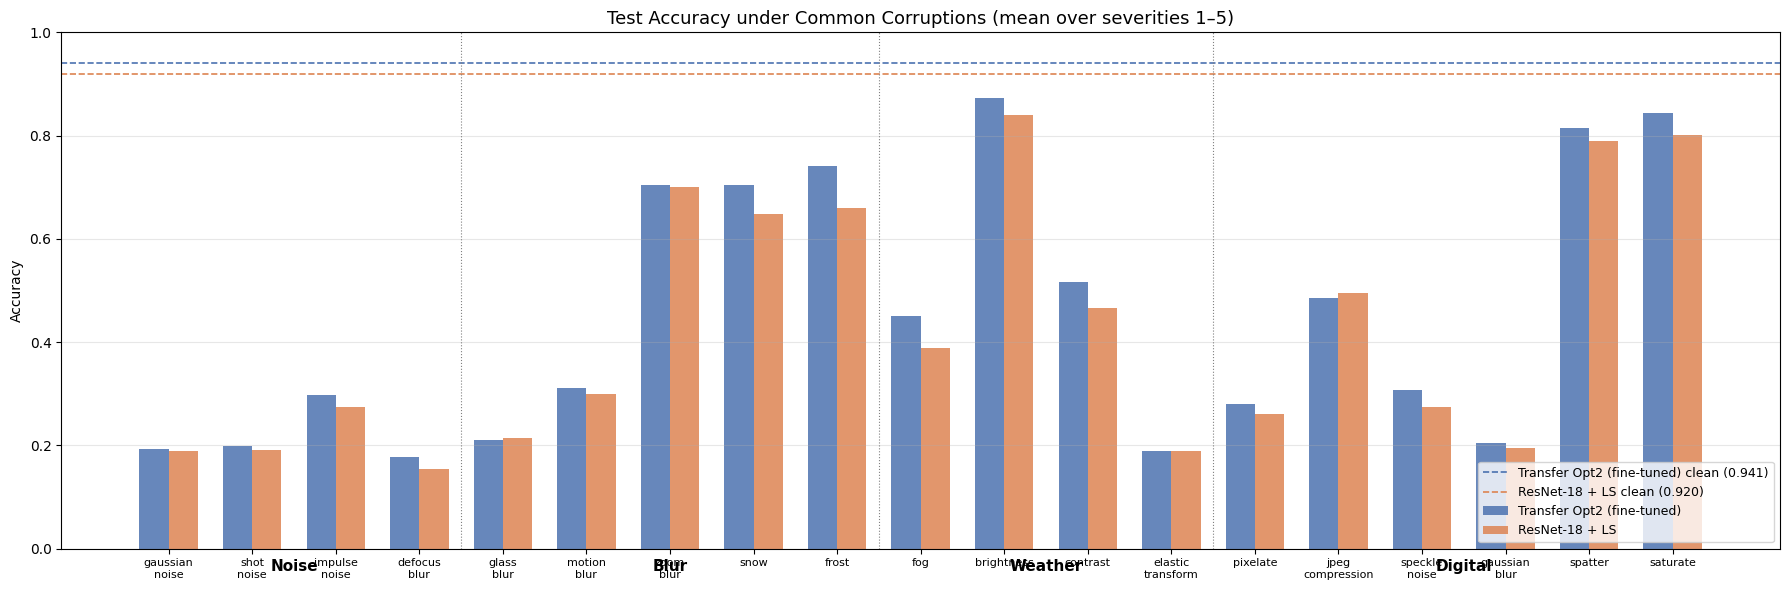

Saved corruption_robustness.png


In [10]:
model_names  = list(MODELS.keys())
colors       = ['#4C72B0', '#DD8452']
n_corruptions = len(ALL_CORRUPTIONS)
x = np.arange(n_corruptions)
width = 0.35

fig, ax = plt.subplots(figsize=(18, 6))

for i, (name, color) in enumerate(zip(model_names, colors)):
    means = [np.mean(results[name][c]) for c in ALL_CORRUPTIONS]
    offset = (i - 0.5) * width
    ax.bar(x + offset, means, width, label=name, color=color, alpha=0.85)

# Clean accuracy reference lines
for name, color in zip(model_names, colors):
    ax.axhline(clean_accs[name], color=color, linestyle='--', linewidth=1.2,
               label=f'{name} clean ({clean_accs[name]:.3f})')

# Group separators and labels
group_positions = []
pos = 0
for group, corruptions in CORRUPTION_GROUPS.items():
    mid = pos + len(corruptions) / 2 - 0.5
    group_positions.append((mid, group))
    if pos > 0:
        ax.axvline(pos - 0.5, color='gray', linestyle=':', linewidth=0.8)
    pos += len(corruptions)

for mid, group in group_positions:
    ax.text(mid, ax.get_ylim()[0] - 0.02, group, ha='center', va='top',
            fontsize=11, fontweight='bold', transform=ax.get_xaxis_transform())

ax.set_xticks(x)
ax.set_xticklabels(
    [c.replace('_', '\n') for c in ALL_CORRUPTIONS],
    fontsize=8, rotation=0
)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.0)
ax.set_title('Test Accuracy under Common Corruptions (mean over severities 1–5)', fontsize=13)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('corruption_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved corruption_robustness.png')

## Visualisation — Accuracy vs. Severity (per corruption)

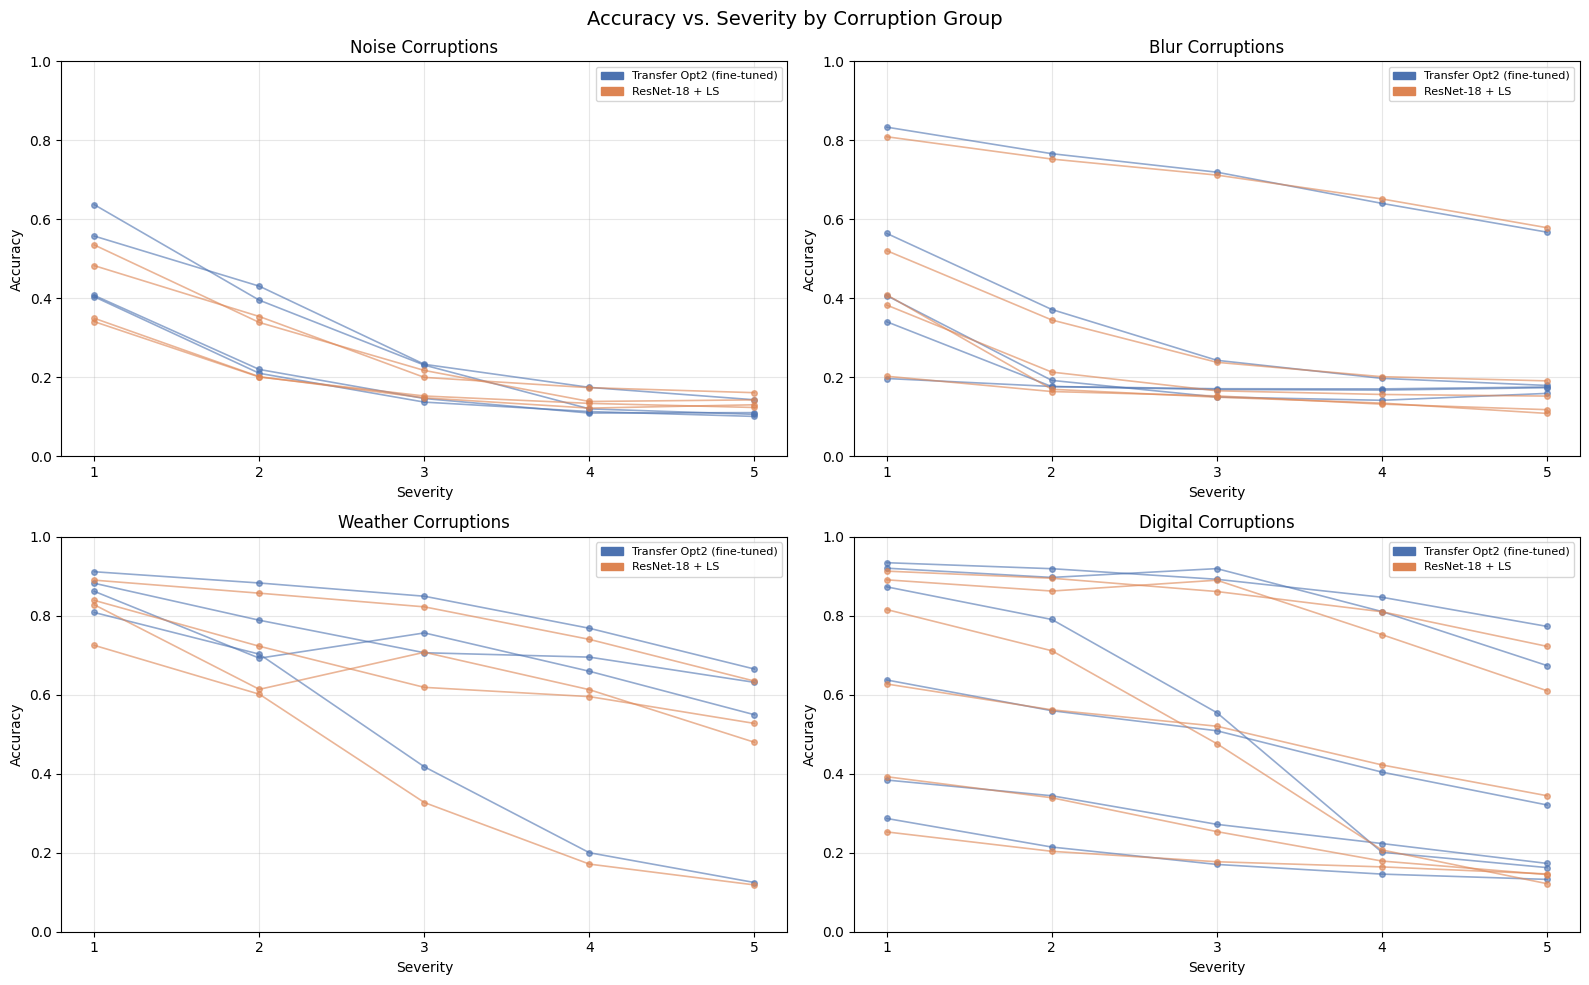

Saved corruption_severity_curves.png


In [11]:
severities = [1, 2, 3, 4, 5]
n_groups   = len(CORRUPTION_GROUPS)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)
axes_flat  = axes.flatten()

for ax, (group, corruptions) in zip(axes_flat, CORRUPTION_GROUPS.items()):
    for name, color in zip(model_names, colors):
        for corruption in corruptions:
            accs = results[name][corruption]
            label = f'{name} – {corruption}' if name == model_names[0] else None
            ax.plot(severities, accs, marker='o', color=color, alpha=0.6,
                    linewidth=1.2, markersize=4)

    # Legend proxy
    handles = [mpatches.Patch(color=c, label=n) for n, c in zip(model_names, colors)]
    ax.legend(handles=handles, fontsize=8)
    ax.set_title(f'{group} Corruptions', fontsize=12)
    ax.set_xlabel('Severity')
    ax.set_ylabel('Accuracy')
    ax.set_xticks(severities)
    ax.set_ylim(0, 1.0)
    ax.grid(alpha=0.3)

fig.suptitle('Accuracy vs. Severity by Corruption Group', fontsize=14)
plt.tight_layout()
plt.savefig('corruption_severity_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved corruption_severity_curves.png')

---
## AugMix Fine-tuning — Robustness Evaluation

ResNet-18 retrained on CIFAR-10 with the **AugMix** framework (Hendrycks et al., ICLR 2020).

Each training sample is converted into three views — one clean and two independently generated augmentation chains — and a **Jensen-Shannon Divergence consistency loss** (λ = 12) is added alongside cross-entropy:

$$\mathcal{L} = \mathrm{CE}(p_\text{orig}, y) + 12 \cdot \underbrace{\frac{1}{3}\!\left[\mathrm{KL}(p_\text{orig}\,\|\,M) + \mathrm{KL}(p_\text{aug1}\,\|\,M) + \mathrm{KL}(p_\text{aug2}\,\|\,M)\right]}_{\text{JSD consistency}}, \quad M = \tfrac{1}{3}(p_\text{orig}+p_\text{aug1}+p_\text{aug2})$$

Operations excluded from augmentation chains (overlap with CIFAR-10-C corruptions): contrast, color, brightness, sharpness, cutout.

**Comparison:** ResNet-18 + Label Smoothing (baseline) vs ResNet-18 + AugMix on clean CIFAR-10 and all 19 corruptions.

### Train ResNet-18 with AugMix

Trains from scratch for 100 epochs with the JSD consistency loss (λ=12). The best checkpoint (by validation accuracy) is saved to .

> **Note:** Each forward pass processes 3× the batch size (orig + aug1 + aug2 concatenated). Reduce  to 21 if you hit GPU OOM.


In [5]:
import sys, copy
import torch
import torch.nn as nn

sys.path.insert(0, '.')
from models.ResNet import ResNet, BasicBlock
from train import get_augmix_loaders, train_one_epoch_augmix, validate
from augmix import JSDLoss

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on: {DEVICE}')

# ── Hyperparameters ──────────────────────────────────────────────────────────
params = {
    'dataset':         'cifar10',
    'data_dir':        './data',
    'num_workers':     2,
    'mean':            (0.4914, 0.4822, 0.4465),
    'std':             (0.2023, 0.1994, 0.2010),
    'num_classes':     10,
    'batch_size':      64,       # effective forward batch = 3x64 = 192
    'learning_rate':   1e-3,
    'weight_decay':    1e-4,
    'epochs':          30,
    'log_interval':    200,
    'label_smoothing': 0.0,
    'use_augmix':      True,
    'augmix_alpha':    1.0,
    'augmix_severity': 3,
    'save_path':       'best_augmix_resnet.pth',
}
N_EPOCHS = params['epochs']

# ── Model ─────────────────────────────────────────────────────────────────────
model = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10).to(DEVICE)

# ── Optimizer / scheduler / loss ──────────────────────────────────────────────
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=params['learning_rate'],
    weight_decay=params['weight_decay'],
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
criterion = JSDLoss(
    num_classes=params['num_classes'],
    lambda_jsd=12.0,
    label_smoothing=params['label_smoothing'],
)
ce_eval = nn.CrossEntropyLoss()   # validation always uses standard CE on clean images

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader, val_loader = get_augmix_loaders(params)

# ── Training loop ─────────────────────────────────────────────────────────────
best_acc, best_weights = 0.0, None
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch_augmix(
        model, train_loader, optimizer, criterion, DEVICE, params['log_interval']
    )
    val_loss, val_acc = validate(model, val_loader, ce_eval, DEVICE)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:3d}/{N_EPOCHS}  '
          f'train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}')

    if val_acc > best_acc:
        best_acc     = val_acc
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, params['save_path'])
        print(f'  => saved best model (val_acc={best_acc:.4f})')

model.load_state_dict(best_weights)
print(f'Training done. Best val accuracy: {best_acc:.4f}')
print(f'Checkpoint saved to: {params["save_path"]}')


Training on: cuda
  [200/782] loss: 2.0199  acc: 0.3178
  [400/782] loss: 1.8837  acc: 0.3741
  [600/782] loss: 1.7834  acc: 0.4214
Epoch   1/30  train_loss=1.7119  train_acc=0.4558  val_loss=1.3711  val_acc=0.5205
  => saved best model (val_acc=0.5205)
  [200/782] loss: 1.3973  acc: 0.6102
  [400/782] loss: 1.3561  acc: 0.6243
  [600/782] loss: 1.3243  acc: 0.6355
Epoch   2/30  train_loss=1.2994  train_acc=0.6458  val_loss=0.9221  val_acc=0.6950
  => saved best model (val_acc=0.6950)
  [200/782] loss: 1.1640  acc: 0.7055
  [400/782] loss: 1.1509  acc: 0.7118
  [600/782] loss: 1.1397  acc: 0.7155
Epoch   3/30  train_loss=1.1253  train_acc=0.7217  val_loss=0.7979  val_acc=0.7305
  => saved best model (val_acc=0.7305)
  [200/782] loss: 1.0564  acc: 0.7510
  [400/782] loss: 1.0425  acc: 0.7548
  [600/782] loss: 1.0315  acc: 0.7592
Epoch   4/30  train_loss=1.0272  train_acc=0.7608  val_loss=0.6885  val_acc=0.7757
  => saved best model (val_acc=0.7757)
  [200/782] loss: 0.9821  acc: 0.7822


In [6]:
import sys, torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imagecorruptions import corrupt, get_corruption_names

sys.path.insert(0, '.')
from models.ResNet import ResNet, BasicBlock

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

CORRUPTION_GROUPS = {
    'Noise':   ['gaussian_noise', 'shot_noise', 'impulse_noise', 'speckle_noise'],
    'Blur':    ['defocus_blur', 'glass_blur', 'motion_blur', 'zoom_blur', 'gaussian_blur'],
    'Weather': ['snow', 'frost', 'fog', 'spatter'],
    'Digital': ['brightness', 'contrast', 'elastic_transform', 'pixelate',
               'jpeg_compression', 'saturate'],
}
ALL_CORRUPTIONS = get_corruption_names('all')

from torchvision import datasets, transforms
_normalize = transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
_to_tensor = transforms.ToTensor()

@torch.no_grad()
def evaluate_on_arrays(model, images_uint8, labels, batch_size=256):
    """Return accuracy of *model* on a uint8 numpy image array (N, H, W, C)."""
    model.eval()
    correct, n = 0, 0
    for i in range(0, len(images_uint8), batch_size):
        batch_imgs = images_uint8[i : i + batch_size]
        batch_lbls = labels[i : i + batch_size]
        tensors = torch.stack([_normalize(_to_tensor(img)) for img in batch_imgs])
        tensors = tensors.to(DEVICE)
        lbls    = torch.tensor(batch_lbls, device=DEVICE)
        preds   = model(tensors).argmax(1)
        correct += preds.eq(lbls).sum().item()
        n       += len(batch_lbls)
    return correct / n

raw_test   = datasets.CIFAR10('data/', train=False, download=True)
raw_images = raw_test.data
raw_labels = np.array(raw_test.targets)
print(f'Test set loaded: {raw_images.shape}')

# ── AugMix fine-tuned ResNet-18 ──────────────────────────────────────────────
augmix_model = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10)
augmix_model.load_state_dict(
    torch.load('best_augmix_resnet.pth', map_location=DEVICE)
)
augmix_model = augmix_model.to(DEVICE).eval()
print('ResNet-18 + AugMix loaded.')

# ── Baseline ResNet-18 + Label Smoothing ──────────────────────────────────────
baseline_model = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10)
baseline_model.load_state_dict(
    torch.load('best_b_resnet_ls.pth', map_location=DEVICE)
)
baseline_model = baseline_model.to(DEVICE).eval()
print('ResNet-18 + LS (baseline) loaded.')


Test set loaded: (10000, 32, 32, 3)
ResNet-18 + AugMix loaded.
ResNet-18 + LS (baseline) loaded.


In [7]:
augmix_clean_acc   = evaluate_on_arrays(augmix_model,   raw_images, raw_labels)
baseline_clean_acc = evaluate_on_arrays(baseline_model, raw_images, raw_labels)

print('Clean CIFAR-10 test accuracy:')
print(f'  ResNet-18 Baseline (+ LS) : {baseline_clean_acc:.4f}')
print(f'  ResNet-18 + AugMix        : {augmix_clean_acc:.4f}')
print(f'  Δ (AugMix − Baseline)     : {augmix_clean_acc - baseline_clean_acc:+.4f}')


Clean CIFAR-10 test accuracy:
  ResNet-18 Baseline (+ LS) : 0.9197
  ResNet-18 + AugMix        : 0.9265
  Δ (AugMix − Baseline)     : +0.0068


In [8]:
# Evaluate both models on all 19 corruptions x 5 severity levels
augmix_results   = {}
baseline_results = {}

for corruption in ALL_CORRUPTIONS:
    aug_accs  = []
    base_accs = []
    for severity in range(1, 6):
        corrupted = np.array(
            [corrupt(img, corruption_name=corruption, severity=severity)
             for img in raw_images]
        )
        aug_accs.append(evaluate_on_arrays(augmix_model,   corrupted, raw_labels))
        base_accs.append(evaluate_on_arrays(baseline_model, corrupted, raw_labels))
    augmix_results[corruption]   = aug_accs
    baseline_results[corruption] = base_accs
    print(f"{corruption:25s}  AugMix: {np.mean(aug_accs):.4f}  "
          f"Baseline: {np.mean(base_accs):.4f}  "
          f"Delta: {np.mean(aug_accs)-np.mean(base_accs):+.4f}")

print("Done.")


gaussian_noise             AugMix: 0.3316  Baseline: 0.1901  Delta: +0.1414
shot_noise                 AugMix: 0.3300  Baseline: 0.1908  Delta: +0.1391
impulse_noise              AugMix: 0.4178  Baseline: 0.2777  Delta: +0.1401
defocus_blur               AugMix: 0.3033  Baseline: 0.1538  Delta: +0.1495
glass_blur                 AugMix: 0.4268  Baseline: 0.2158  Delta: +0.2110
motion_blur                AugMix: 0.4589  Baseline: 0.3000  Delta: +0.1589
zoom_blur                  AugMix: 0.8691  Baseline: 0.7007  Delta: +0.1683
snow                       AugMix: 0.7228  Baseline: 0.6473  Delta: +0.0755
frost                      AugMix: 0.7783  Baseline: 0.6600  Delta: +0.1183
fog                        AugMix: 0.5024  Baseline: 0.3912  Delta: +0.1111
brightness                 AugMix: 0.8875  Baseline: 0.8406  Delta: +0.0469
contrast                   AugMix: 0.6672  Baseline: 0.4664  Delta: +0.2008
elastic_transform          AugMix: 0.2780  Baseline: 0.1890  Delta: +0.0890
pixelate    

/home/rodor/Desktop/dersler/515/mert_rodop_cs_515_hw2/Deep-learning/cs515/lib/python3.10/site-packages/imagecorruptions/corruptions.py:430: RuntimeWarning: invalid value encountered in divide
  m /= np.max(m, axis=(0, 1))
/home/rodor/Desktop/dersler/515/mert_rodop_cs_515_hw2/Deep-learning/cs515/lib/python3.10/site-packages/imagecorruptions/__init__.py:69: RuntimeWarning: invalid value encountered in cast
  return np.uint8(image_corrupted)


spatter                    AugMix: 0.8530  Baseline: 0.7878  Delta: +0.0652
saturate                   AugMix: 0.8614  Baseline: 0.8013  Delta: +0.0601
Done.


In [9]:
# Per-corruption comparison table
rows = []
for corruption in ALL_CORRUPTIONS:
    base_mean = np.mean(baseline_results[corruption])
    augm_mean = np.mean(augmix_results[corruption])
    rows.append({
        'Corruption':        corruption,
        'Baseline mCA':      base_mean,
        'AugMix mCA':        augm_mean,
        'Δ (AugMix − Base)': augm_mean - base_mean,
    })

compare_df = pd.DataFrame(rows).set_index('Corruption')

# Prepend CLEAN row
clean_cmp = pd.DataFrame([{
    'Corruption':        'CLEAN',
    'Baseline mCA':      baseline_clean_acc,
    'AugMix mCA':        augmix_clean_acc,
    'Δ (AugMix − Base)': augmix_clean_acc - baseline_clean_acc,
}]).set_index('Corruption')
compare_df = pd.concat([clean_cmp, compare_df])

pd.set_option('display.float_format', '{:.4f}'.format)
print('Per-corruption accuracy — Baseline vs AugMix (mean over severities 1–5):')
display(compare_df.round(4))


Per-corruption accuracy — Baseline vs AugMix (mean over severities 1–5):


,Baseline mCA,AugMix mCA,Δ (AugMix − Base)
Corruption,,,
CLEAN,0.9197,0.9265,0.0068
gaussian_noise,0.1901,0.3316,0.1414
shot_noise,0.1908,0.3300,0.1391
impulse_noise,0.2777,0.4178,0.1401
defocus_blur,0.1538,0.3033,0.1495
glass_blur,0.2158,0.4268,0.2110
motion_blur,0.3000,0.4589,0.1589
zoom_blur,0.7007,0.8691,0.1683
snow,0.6473,0.7228,0.0755


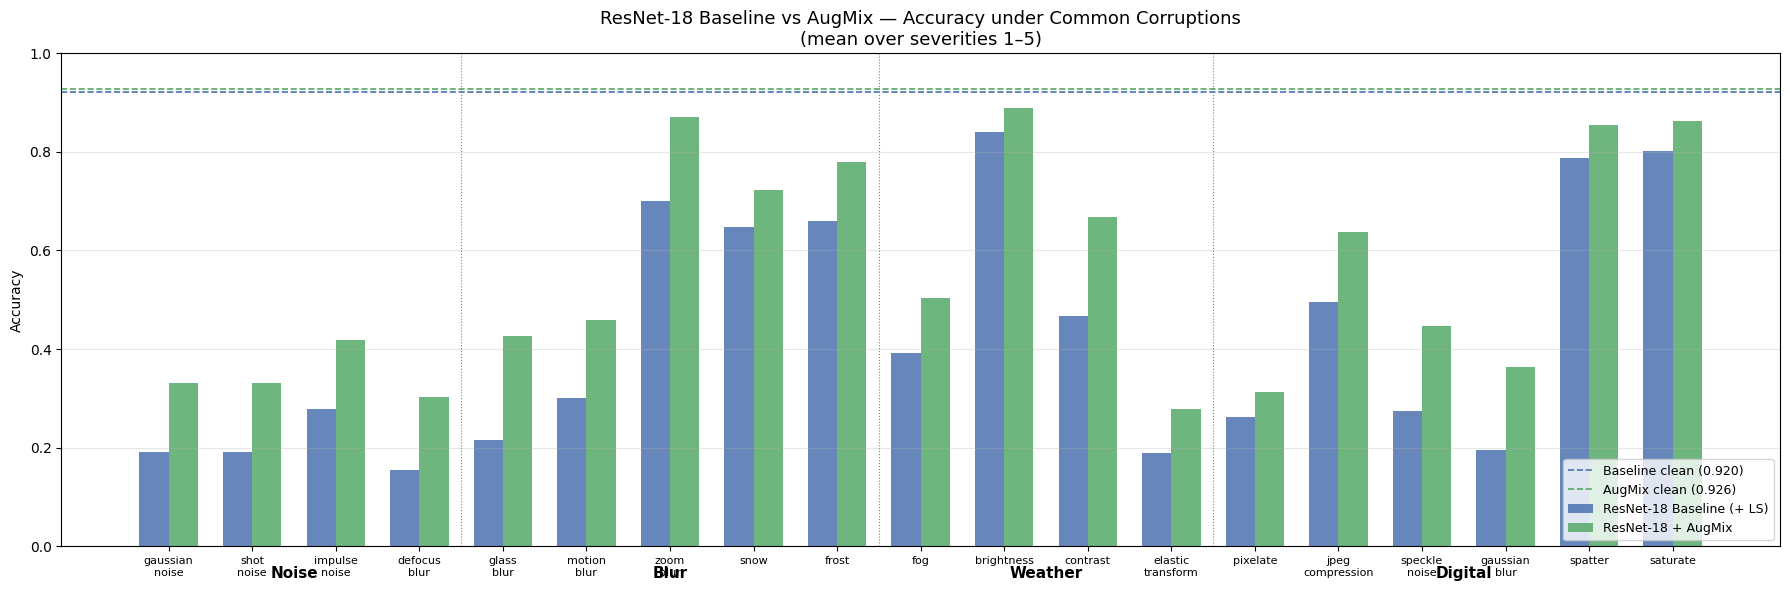

Saved augmix_vs_baseline.png


In [10]:
fig, ax = plt.subplots(figsize=(18, 6))

x     = np.arange(len(ALL_CORRUPTIONS))
width = 0.35

baseline_means = [np.mean(baseline_results[c]) for c in ALL_CORRUPTIONS]
augmix_means   = [np.mean(augmix_results[c])   for c in ALL_CORRUPTIONS]

ax.bar(x - width / 2, baseline_means, width, label='ResNet-18 Baseline (+ LS)',
       color='#4C72B0', alpha=0.85)
ax.bar(x + width / 2, augmix_means,   width, label='ResNet-18 + AugMix',
       color='#55A868', alpha=0.85)

ax.axhline(baseline_clean_acc, color="#4C72B0", linestyle="--", linewidth=1.2,
           label=f"Baseline clean ({baseline_clean_acc:.3f})")
ax.axhline(augmix_clean_acc,   color="#55A868", linestyle="--", linewidth=1.2,
           label=f"AugMix clean ({augmix_clean_acc:.3f})")

pos = 0
for group, corruptions in CORRUPTION_GROUPS.items():
    mid = pos + len(corruptions) / 2 - 0.5
    if pos > 0:
        ax.axvline(pos - 0.5, color="gray", linestyle=":", linewidth=0.8)
    ax.text(mid, -0.04, group, ha="center", va="top", fontsize=11,
            fontweight="bold", transform=ax.get_xaxis_transform())
    pos += len(corruptions)

ax.set_xticks(x)
ax.set_xticklabels([c.replace("_", "\n") for c in ALL_CORRUPTIONS], fontsize=8)  # fix 1
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.0)
ax.set_title("ResNet-18 Baseline vs AugMix — Accuracy under Common Corruptions\n"  # fix 2
             "(mean over severities 1–5)", fontsize=13)
ax.legend(fontsize=9, loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig('augmix_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved augmix_vs_baseline.png')

In [11]:
# ── Grouped mCA and final summary ──────────────────────────────────────────────
aug_group  = {}
base_group = {}
for group, corruptions in CORRUPTION_GROUPS.items():
    aug_group[group]  = np.mean([np.mean(augmix_results[c])   for c in corruptions])
    base_group[group] = np.mean([np.mean(baseline_results[c]) for c in corruptions])

aug_overall  = np.mean([np.mean(augmix_results[c])   for c in ALL_CORRUPTIONS])
base_overall = np.mean([np.mean(baseline_results[c]) for c in ALL_CORRUPTIONS])

aug_group['Overall mCA']  = aug_overall
base_group['Overall mCA'] = base_overall

group_compare = pd.DataFrame({
    'Baseline (ResNet-18 + LS)': base_group,
    'AugMix (ResNet-18)':        aug_group,
})
group_compare['Δ (AugMix − Base)'] = (
    group_compare['AugMix (ResNet-18)'] - group_compare['Baseline (ResNet-18 + LS)']
)

print('Clean test accuracy')
print(f'  Baseline : {baseline_clean_acc:.4f}')
print(f'  AugMix   : {augmix_clean_acc:.4f}')
print(f'  Δ        : {augmix_clean_acc - baseline_clean_acc:+.4f}')
print()
print('Mean Corruption Accuracy (mCA) by group:')
display(group_compare.round(4))


Clean test accuracy
  Baseline : 0.9197
  AugMix   : 0.9265
  Δ        : +0.0068

Mean Corruption Accuracy (mCA) by group:


,Baseline (ResNet-18 + LS),AugMix (ResNet-18),Δ (AugMix − Base)
Noise,0.2332,0.3816,0.1484
Blur,0.3129,0.4843,0.1714
Weather,0.6216,0.7141,0.0925
Digital,0.5091,0.6073,0.0982
Overall mCA,0.4230,0.5499,0.1268


---
## Adversarial Robustness — PGD Attack Evaluation

Evaluates both the **standard** (ResNet-18 + LS) and **AugMix** checkpoints against PGD-20 (Madry et al., ICLR 2018) under two threat models:

| Attack | Norm | ε |
|--------|------|---|
| PGD20-L∞ | L∞ | 4/255 |
| PGD20-L2 | L2 | 0.25 |

Step size = 2.5 × ε / 20, random start, 20 iterations.

Delta is maintained in **pixel space** [0, 1]; normalisation/denormalisation is handled inside `pgd_attack.py`.


In [12]:
import sys, os, torch
import numpy as np
import pandas as pd

sys.path.insert(0, '.')
from models.ResNet import ResNet, BasicBlock
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from pgd_attack import PGD20_LINF, PGD20_L2, evaluate_adversarial

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = './outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck',
]

test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])
test_ds     = datasets.CIFAR10('./data', train=False, download=True, transform=test_tf)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2)

standard_model = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10)
standard_model.load_state_dict(torch.load('best_b_resnet_ls.pth', map_location=DEVICE))
standard_model = standard_model.to(DEVICE).eval()
print('Standard model loaded.')

augmix_model = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10)
augmix_model.load_state_dict(torch.load('best_augmix_resnet.pth', map_location=DEVICE))
augmix_model = augmix_model.to(DEVICE).eval()
print('AugMix model loaded.')

MODELS = {
    'Standard (ResNet-18 + LS)': standard_model,
    'AugMix (ResNet-18)':        augmix_model,
}
ATTACKS = {
    'PGD20-Linf': PGD20_LINF,
    'PGD20-L2':   PGD20_L2,
}
print(f'Device: {DEVICE}')


Standard model loaded.
AugMix model loaded.
Device: cuda


In [13]:
results_adv = {name: {} for name in MODELS}

for model_name, model in MODELS.items():
    for attack_name, cfg in ATTACKS.items():
        print(f'\n{"="*60}')
        print(f'{model_name}  |  {attack_name}')
        print(f'{"="*60}')
        res = evaluate_adversarial(model, test_loader, cfg, DEVICE)
        results_adv[model_name][attack_name] = res

print('\nAll evaluations complete.')



Standard (ResNet-18 + LS)  |  PGD20-Linf
  Batch   1/79  clean: 0.9453  adv: 0.2109  fooled so far: 94
  Batch   2/79  clean: 0.9219  adv: 0.1758  fooled so far: 191
  Batch   3/79  clean: 0.9245  adv: 0.1849  fooled so far: 284
  Batch   4/79  clean: 0.9297  adv: 0.1953  fooled so far: 376
  Batch   5/79  clean: 0.9391  adv: 0.2031  fooled so far: 471
  Batch   6/79  clean: 0.9336  adv: 0.1953  fooled so far: 567
  Batch   7/79  clean: 0.9297  adv: 0.1942  fooled so far: 659
  Batch   8/79  clean: 0.9277  adv: 0.1924  fooled so far: 753
  Batch   9/79  clean: 0.9262  adv: 0.1953  fooled so far: 842
  Batch  10/79  clean: 0.9234  adv: 0.1953  fooled so far: 932
  Batch  11/79  clean: 0.9233  adv: 0.1932  fooled so far: 1028
  Batch  12/79  clean: 0.9238  adv: 0.1868  fooled so far: 1132
  Batch  13/79  clean: 0.9255  adv: 0.1851  fooled so far: 1232
  Batch  14/79  clean: 0.9247  adv: 0.1842  fooled so far: 1327
  Batch  15/79  clean: 0.9245  adv: 0.1865  fooled so far: 1417
  Batch  

In [14]:
rows = []
for model_name in MODELS:
    for attack_name in ATTACKS:
        r = results_adv[model_name][attack_name]
        rows.append({
            'Model':     model_name,
            'Attack':    attack_name,
            'Clean Acc': f"{r['clean_acc']*100:.1f}%",
            'Adv Acc':   f"{r['adv_acc']*100:.1f}%",
            '# Fooled':  r['num_fooled'],
        })

summary_df = pd.DataFrame(rows)
print('\nAdversarial Robustness Summary')
print('=' * 62)
print(summary_df.to_string(index=False))
print('=' * 62)



Adversarial Robustness Summary
                    Model     Attack Clean Acc Adv Acc  # Fooled
Standard (ResNet-18 + LS) PGD20-Linf     92.0%   19.0%      7300
Standard (ResNet-18 + LS)   PGD20-L2     92.0%   41.1%      5090
       AugMix (ResNet-18) PGD20-Linf     92.7%    1.4%      9129
       AugMix (ResNet-18)   PGD20-L2     92.7%   26.8%      6590


---
## Grad-CAM Visualization

For samples where the **clean prediction is correct but the adversarial prediction is wrong**, we visualise the network attention using Grad-CAM (Selvaraju et al., ICCV 2017).

Target layer: `model.layer4[-1]` (last BasicBlock of ResNet-18).

Each figure: **[Clean] [Grad-CAM clean] [Adversarial] [Grad-CAM adv]**


In [15]:
from gradcam import visualize_gradcam
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

N_GRADCAM = 2

for model_name, model in MODELS.items():
    tag = 'standard' if 'Standard' in model_name else 'augmix'
    print(f'\nGrad-CAM — {model_name} (PGD20-Linf misclassified samples)')
    samples = results_adv[model_name]['PGD20-Linf']['misclassified']
    visualize_gradcam(
        model        = model,
        target_layer = model.layer4[-1],
        samples      = samples,
        output_dir   = OUTPUT_DIR,
        tag          = tag,
        n_samples    = N_GRADCAM,
        device       = DEVICE,
    )

# Display inline
for model_name in MODELS:
    tag = 'standard' if 'Standard' in model_name else 'augmix'
    for i in range(N_GRADCAM):
        path = os.path.join(OUTPUT_DIR, f'gradcam_sample_{i}_{tag}.png')
        if os.path.isfile(path):
            img = mpimg.imread(path)
            fig, ax = plt.subplots(figsize=(14, 3.5))
            ax.imshow(img)
            ax.axis('off')
            plt.tight_layout()
            plt.show()



Grad-CAM — Standard (ResNet-18 + LS) (PGD20-Linf misclassified samples)
  Saved ./outputs/gradcam_sample_0_standard.png
  Saved ./outputs/gradcam_sample_1_standard.png
[Grad-CAM] Done — 2 figure(s) saved for tag=standard.

Grad-CAM — AugMix (ResNet-18) (PGD20-Linf misclassified samples)
  Saved ./outputs/gradcam_sample_0_augmix.png
  Saved ./outputs/gradcam_sample_1_augmix.png
[Grad-CAM] Done — 2 figure(s) saved for tag=augmix.


/tmp/ipykernel_31794/1417236015.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---
## t-SNE Feature Space Visualization

Extracts 512-dim penultimate-layer features (after `avgpool`, before `linear`) for 1 000 clean + 1 000 adversarial images, then fits t-SNE on the **combined** matrix so both point sets share the same 2-D embedding.

Two plots per (model × attack norm):
1. **By class** — 10 colours, ○ = clean, ✕ = adversarial
2. **Clean vs adv** — blue = clean, red = adversarial


In [2]:
import sys, os, torch
import numpy as np

sys.path.insert(0, '.')
from models.ResNet import ResNet, BasicBlock
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from tsne_viz import TSNEConfig, extract_features, run_tsne_and_plot
from pgd_attack import pgd_attack, PGD20_LINF, PGD20_L2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = './outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])
test_ds     = datasets.CIFAR10('./data', train=False, download=True, transform=test_tf)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2)

standard_model = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10)
standard_model.load_state_dict(torch.load('best_b_resnet_ls.pth', map_location=DEVICE))
standard_model = standard_model.to(DEVICE).eval()

augmix_model = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10)
augmix_model.load_state_dict(torch.load('best_augmix_resnet.pth', map_location=DEVICE))
augmix_model = augmix_model.to(DEVICE).eval()

MODELS = {
    'Standard (ResNet-18 + LS)': standard_model,
    'AugMix (ResNet-18)':        augmix_model,
}
ATTACKS = {
    'PGD20-Linf': PGD20_LINF,
    'PGD20-L2':   PGD20_L2,
}

tsne_cfg = TSNEConfig(n_samples=1000, perplexity=30, n_iter=1000, random_state=42)

# Collect all test images as a flat tensor (needed for subsample indexing)
all_imgs = torch.cat([b[0] for b in test_loader], dim=0)   # (10000, 3, 32, 32)
all_lbls = torch.cat([b[1] for b in test_loader], dim=0)   # (10000,)

for model_name, model in MODELS.items():
    tag = 'standard' if 'Standard' in model_name else 'augmix'
    for attack_name, cfg in ATTACKS.items():
        norm_str = 'linf' if 'Linf' in attack_name else 'l2'
        print(f'\nt-SNE: {model_name}  |  {attack_name}')

        # Subsample BEFORE generating adversarial examples
        rng      = np.random.default_rng(42)
        idx      = rng.choice(len(all_imgs), tsne_cfg.n_samples, replace=False)
        sub_imgs = all_imgs[idx].to(DEVICE)
        sub_lbls = all_lbls[idx].to(DEVICE)

        # Generate adversarial versions of the subsample
        adv_sub = pgd_attack(model, sub_imgs, sub_lbls, cfg, DEVICE)

        # DataLoader for feature extraction
        sub_loader = DataLoader(
            TensorDataset(sub_imgs.cpu(), sub_lbls.cpu()),
            batch_size=256, shuffle=False,
        )

        feats, lbls, is_adv = extract_features(
            model, sub_loader, DEVICE,
            adv_images=adv_sub.cpu(),
            n_samples=tsne_cfg.n_samples,
        )

        run_tsne_and_plot(
            features=feats, labels=lbls, is_adv=is_adv,
            output_dir=OUTPUT_DIR, tag=tag, norm=norm_str, cfg=tsne_cfg,
        )

# Display saved plots inline
for model_name in MODELS:
    tag = 'standard' if 'Standard' in model_name else 'augmix'
    for norm_str in ['linf', 'l2']:
        for suffix in ['by_class', 'clean_vs_adv']:
            path = os.path.join(OUTPUT_DIR, f'tsne_{tag}_{norm_str}_{suffix}.png')
            if os.path.isfile(path):
                fig, ax = plt.subplots(figsize=(9, 7))
                ax.imshow(mpimg.imread(path))
                ax.axis('off')
                plt.tight_layout()
                plt.show()



t-SNE: Standard (ResNet-18 + LS)  |  PGD20-Linf
[t-SNE] Fitting on 2000 points (tag=standard, norm=linf) …
[t-SNE] Done.
  Saved ./outputs/tsne_standard_linf_by_class.png
  Saved ./outputs/tsne_standard_linf_clean_vs_adv.png

t-SNE: Standard (ResNet-18 + LS)  |  PGD20-L2
[t-SNE] Fitting on 2000 points (tag=standard, norm=l2) …
[t-SNE] Done.
  Saved ./outputs/tsne_standard_l2_by_class.png
  Saved ./outputs/tsne_standard_l2_clean_vs_adv.png

t-SNE: AugMix (ResNet-18)  |  PGD20-Linf
[t-SNE] Fitting on 2000 points (tag=augmix, norm=linf) …
[t-SNE] Done.
  Saved ./outputs/tsne_augmix_linf_by_class.png
  Saved ./outputs/tsne_augmix_linf_clean_vs_adv.png

t-SNE: AugMix (ResNet-18)  |  PGD20-L2
[t-SNE] Fitting on 2000 points (tag=augmix, norm=l2) …
[t-SNE] Done.
  Saved ./outputs/tsne_augmix_l2_by_class.png
  Saved ./outputs/tsne_augmix_l2_clean_vs_adv.png


/tmp/ipykernel_40860/2958830994.py:93: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---

## Knowledge Distillation with AugMix Teacher

We now test whether the AugMix-trained ResNet-18 (which is more robust to distribution shift) is a better **teacher** for knowledge distillation than the standard ResNet teachers used in HW2.

Two KD variants are evaluated:
- **TGLS-D**: Teacher-Guided Label Smoothing (dynamic smoothing from teacher confidence), T=1.0 — mirrors TGLS-B/C but uses AugMix teacher
- **KD-AugMix**: Standard Hinton KD (T=4.0, α=0.7) with the AugMix teacher

All prior MobileNetV2 students (TGLS-B, TGLS-C, scratch) are loaded from their saved checkpoints for comparison.

In [1]:
import sys
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '.')
from models.ResNet import ResNet, BasicBlock
from models.mobilenet import MobileNetV2
from train import run_kd_training, validate, get_loaders, DistillationLoss, TeacherGuidedLSLoss
from ptflops import get_model_complexity_info

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

B_PARAMS = {
    'dataset': 'cifar10', 'data_dir': './data', 'num_workers': 2,
    'mean': (0.4914, 0.4822, 0.4465), 'std': (0.2023, 0.1994, 0.2010),
    'batch_size': 128, 'learning_rate': 1e-3, 'weight_decay': 1e-4,
    'epochs': 30, 'log_interval': 100, 'resize_224': False,
    'label_smoothing': 0.0, 'kd_temperature': 4.0, 'kd_alpha': 0.7,
}

_, b_val_loader = get_loaders(B_PARAMS)
ce_eval = nn.CrossEntropyLoss()

# Load the AugMix teacher (same model as augmix_model above, reloaded for cell independence)
augmix_teacher = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10).to(DEVICE)
augmix_teacher.load_state_dict(torch.load('best_augmix_resnet.pth', map_location=DEVICE))
augmix_teacher.eval()

_, teacher_acc = validate(augmix_teacher, b_val_loader, ce_eval, DEVICE)
print(f'AugMix teacher val accuracy: {teacher_acc*100:.2f}%')

AugMix teacher val accuracy: 92.65%


In [2]:
# TGLS-D: MobileNetV2 student with AugMix teacher using Teacher-Guided Label Smoothing
student_tgls_d = MobileNetV2(num_classes=10).to(DEVICE)

hist_tgls_d = run_kd_training(
    student_tgls_d,
    augmix_teacher,
    {**B_PARAMS, 'save_path': 'best_b_mobilenet_tgls_d.pth'},
    DEVICE,
    criterion=TeacherGuidedLSLoss(temperature=1.0),
)
print(f'TGLS-D best val acc: {max(hist_tgls_d["val_acc"])*100:.2f}%')

  [100/391] loss: 1.9368  acc: 0.3133
  [200/391] loss: 1.8122  acc: 0.3796
  [300/391] loss: 1.7313  acc: 0.4197

Epoch 1/30  train_acc=0.4476  val_acc=0.5645
  Saved best model (val_acc=0.5645)
  [100/391] loss: 1.3931  acc: 0.5839
  [200/391] loss: 1.3608  acc: 0.5993
  [300/391] loss: 1.3339  acc: 0.6124

Epoch 2/30  train_acc=0.6235  val_acc=0.6777
  Saved best model (val_acc=0.6777)
  [100/391] loss: 1.1793  acc: 0.6868
  [200/391] loss: 1.1597  acc: 0.6943
  [300/391] loss: 1.1406  acc: 0.7034

Epoch 3/30  train_acc=0.7100  val_acc=0.7372
  Saved best model (val_acc=0.7372)
  [100/391] loss: 1.0437  acc: 0.7524
  [200/391] loss: 1.0314  acc: 0.7561
  [300/391] loss: 1.0267  acc: 0.7576

Epoch 4/30  train_acc=0.7626  val_acc=0.7633
  Saved best model (val_acc=0.7633)
  [100/391] loss: 0.9656  acc: 0.7839
  [200/391] loss: 0.9688  acc: 0.7851
  [300/391] loss: 0.9624  acc: 0.7877

Epoch 5/30  train_acc=0.7895  val_acc=0.7830
  Saved best model (val_acc=0.7830)
  [100/391] loss: 0.

In [3]:
# KD-AugMix: MobileNetV2 student with AugMix teacher using standard Hinton KD
student_kd_augmix = MobileNetV2(num_classes=10).to(DEVICE)

hist_kd_augmix = run_kd_training(
    student_kd_augmix,
    augmix_teacher,
    {**B_PARAMS, 'save_path': 'best_b_mobilenet_kd_augmix.pth'},
    DEVICE,
    criterion=DistillationLoss(temperature=4.0, alpha=0.7),
)
print(f'KD-AugMix best val acc: {max(hist_kd_augmix["val_acc"])*100:.2f}%')

  [100/391] loss: 2.1435  acc: 0.3341
  [200/391] loss: 1.8912  acc: 0.3959
  [300/391] loss: 1.7156  acc: 0.4397

Epoch 1/30  train_acc=0.4715  val_acc=0.5864
  Saved best model (val_acc=0.5864)
  [100/391] loss: 1.0622  acc: 0.6122
  [200/391] loss: 0.9892  acc: 0.6312
  [300/391] loss: 0.9313  acc: 0.6495

Epoch 2/30  train_acc=0.6602  val_acc=0.7127
  Saved best model (val_acc=0.7127)
  [100/391] loss: 0.6856  acc: 0.7266
  [200/391] loss: 0.6729  acc: 0.7325
  [300/391] loss: 0.6522  acc: 0.7396

Epoch 3/30  train_acc=0.7427  val_acc=0.7737
  Saved best model (val_acc=0.7737)
  [100/391] loss: 0.5398  acc: 0.7743
  [200/391] loss: 0.5397  acc: 0.7771
  [300/391] loss: 0.5291  acc: 0.7816

Epoch 4/30  train_acc=0.7847  val_acc=0.7899
  Saved best model (val_acc=0.7899)
  [100/391] loss: 0.4682  acc: 0.8063
  [200/391] loss: 0.4663  acc: 0.8054
  [300/391] loss: 0.4556  acc: 0.8097

Epoch 5/30  train_acc=0.8096  val_acc=0.8099
  Saved best model (val_acc=0.8099)
  [100/391] loss: 0.

In [4]:
# Load all prior models from HW2 checkpoints for comparison
def load_resnet(path):
    m = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10)
    m.load_state_dict(torch.load(path, map_location=DEVICE))
    return m.to(DEVICE).eval()

def load_mobilenet(path):
    m = MobileNetV2(num_classes=10)
    m.load_state_dict(torch.load(path, map_location=DEVICE))
    return m.to(DEVICE).eval()

resnet_no_ls   = load_resnet('best_b_resnet_no_ls.pth')
resnet_ls      = load_resnet('best_b_resnet_ls.pth')
mobilenet_base = load_mobilenet('best_b_mobilenet.pth')
student_tgls_b = load_mobilenet('best_b_mobilenet_tgls_b.pth')
student_tgls_c = load_mobilenet('best_b_mobilenet_tgls_c.pth')
print('All prior models loaded.')

All prior models loaded.


In [5]:
from ptflops import get_model_complexity_info

rows = []
for name, mdl, hist in [
    ('ResNet-18 (no LS)',              resnet_no_ls,      None),
    ('ResNet-18 (LS=0.1)',             resnet_ls,         None),
    ('ResNet-18 (AugMix) [teacher]',   augmix_teacher,    None),
    ('MobileNetV2 scratch',            mobilenet_base,    None),
    ('MobileNetV2 TGLS-B (no-LS T)',   student_tgls_b,    None),
    ('MobileNetV2 TGLS-C (LS T)',      student_tgls_c,    None),
    ('MobileNetV2 TGLS-D (AugMix T)',  student_tgls_d,    hist_tgls_d),
    ('MobileNetV2 KD-AugMix (Hinton)', student_kd_augmix, hist_kd_augmix),
]:
    macs, n_params = get_model_complexity_info(
        mdl, (3, 32, 32), as_strings=False,
        print_per_layer_stat=False, verbose=False,
    )
    _, val_acc = validate(mdl, b_val_loader, ce_eval, DEVICE)
    # For newly trained models use best checkpoint acc from history;
    # for loaded checkpoints the checkpoint already stores best weights so live acc == best
    best_val = f'{max(hist["val_acc"])*100:.2f}%' if hist is not None else f'{val_acc*100:.2f}%'
    rows.append({
        'Model':        name,
        'Val Acc':      f'{val_acc*100:.2f}%',
        'Best Val Acc': best_val,
        'MACs (M)':     f'{macs/1e6:.2f}',
        'Params (M)':   f'{n_params/1e6:.3f}',
    })

pd.DataFrame(rows)

,Model,Val Acc,Best Val Acc,MACs (M),Params (M)
0,ResNet-18 (no LS),91.89%,91.89%,557.22,11.174
1,ResNet-18 (LS=0.1),91.97%,91.97%,557.22,11.174
2,ResNet-18 (AugMix) [teacher],92.65%,92.65%,557.22,0.000
3,MobileNetV2 scratch,89.23%,89.23%,96.16,2.297
4,MobileNetV2 TGLS-B (no-LS T),89.56%,89.56%,96.16,2.297
5,MobileNetV2 TGLS-C (LS T),89.72%,89.72%,96.16,2.297
6,MobileNetV2 TGLS-D (AugMix T),90.21%,90.21%,96.16,2.297
7,MobileNetV2 KD-AugMix (Hinton),90.72%,90.72%,96.16,2.297


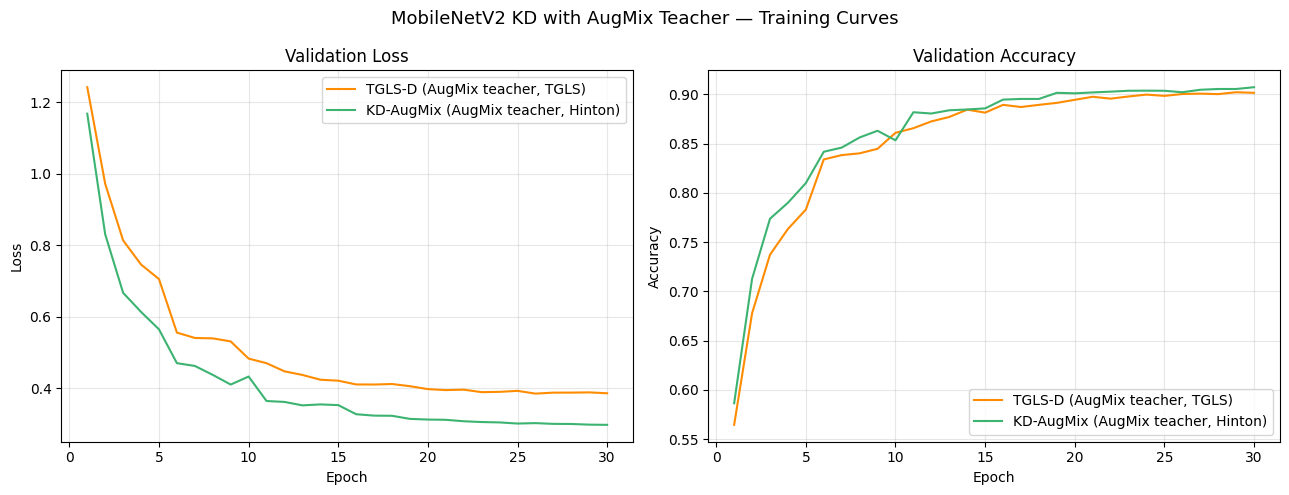

In [6]:
# Training curves for the two new students
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, h, color in [
    ('TGLS-D (AugMix teacher, TGLS)',      hist_tgls_d,    'darkorange'),
    ('KD-AugMix (AugMix teacher, Hinton)', hist_kd_augmix, 'mediumseagreen'),
]:
    ep = range(1, len(h['val_acc']) + 1)
    axes[0].plot(ep, h['val_loss'], label=name, color=color)
    axes[1].plot(ep, h['val_acc'],  label=name, color=color)

for ax, title, ylabel in [
    (axes[0], 'Validation Loss',     'Loss'),
    (axes[1], 'Validation Accuracy', 'Accuracy'),
]:
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('MobileNetV2 KD with AugMix Teacher — Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('./outputs/kd_augmix_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

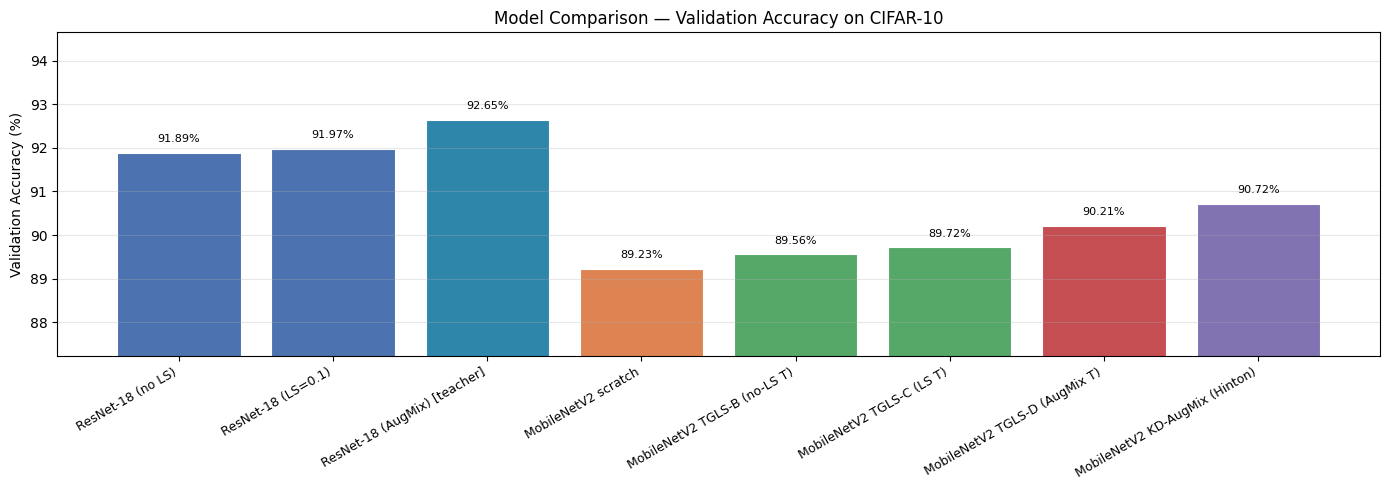

In [7]:
# Bar chart: val accuracy comparison across all models
names = [r['Model'] for r in rows]
accs  = [float(r['Val Acc'].rstrip('%')) for r in rows]

# Colors: blue for ResNets (teachers), orange for MobileNet scratch, green shades for KD students
colors = ['#4C72B0', '#4C72B0', '#2E86AB',  # ResNets
          '#DD8452',                          # MobileNet scratch
          '#55A868', '#55A868',               # old KD students (TGLS-B, TGLS-C)
          '#C44E52', '#8172B2']               # new AugMix KD students

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(names)), accs, color=colors, edgecolor='white', linewidth=0.8)

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Validation Accuracy (%)')
ax.set_ylim(min(accs) - 2, max(accs) + 2)
ax.set_title('Model Comparison — Validation Accuracy on CIFAR-10')
ax.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('./outputs/kd_augmix_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Adversarial Transferability: Teacher → Student

We evaluate whether adversarial examples crafted against the **AugMix teacher** transfer to the student models. This tests *black-box* adversarial robustness: if an attacker only has access to the teacher, can they fool the distilled student?

Attack: **PGD-20 L∞, ε = 4/255** — the same threat model as in the earlier adversarial robustness section.

For each target model we report:
- **Clean Acc** — accuracy on unperturbed test images
- **Adv Acc (teacher attack)** — accuracy when inputs are adversarial w.r.t. the AugMix teacher
- **Transfer Rate** — fraction of teacher-fooled samples that also fool the target (higher = more transferable)

In [3]:
import sys, os, torch
import pandas as pd

sys.path.insert(0, '.')
from pgd_attack import pgd_attack, PGD20_LINF
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = './outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])
test_ds     = datasets.CIFAR10('./data', train=False, download=False, transform=test_tf)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2)


def evaluate_transfer(source_model, target_model, loader, cfg, device):
    """Generate PGD adversarial examples on source_model; evaluate on target_model.

    This tests adversarial transferability: adversarial examples are crafted
    to fool `source_model` (white-box), then fed to `target_model` (black-box).
    """
    source_model.eval()
    target_model.eval()

    clean_correct = adv_correct = n = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        # Clean accuracy measured on the target model
        with torch.no_grad():
            clean_preds = target_model(images).argmax(1)

        # Adversarial examples generated from the SOURCE model
        adv_images = pgd_attack(source_model, images, labels, cfg, device)

        # Evaluate those adversarial examples on the TARGET model
        with torch.no_grad():
            adv_preds = target_model(adv_images).argmax(1)

        clean_correct += clean_preds.eq(labels).sum().item()
        adv_correct   += adv_preds.eq(labels).sum().item()
        n             += images.size(0)

        print(f'  Batch {batch_idx+1:3d}/{len(loader)}'
              f'  clean: {clean_correct/n:.4f}  adv (transferred): {adv_correct/n:.4f}')

    n_fooled = clean_correct - adv_correct
    transfer_rate = n_fooled / clean_correct if clean_correct > 0 else 0.0
    return {
        'clean_acc':     clean_correct / n,
        'adv_acc':       adv_correct   / n,
        'num_transferred': n_fooled,
        'transfer_rate': transfer_rate,
    }


print('Transfer evaluation utilities ready.')

Transfer evaluation utilities ready.


In [4]:
# Load all models needed for the transferability evaluation
# (re-loaded here so this section runs independently of the KD training cells above)
from models.ResNet import ResNet, BasicBlock
from models.mobilenet import MobileNetV2
import torch

def _load_resnet(path):
    m = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10)
    m.load_state_dict(torch.load(path, map_location=DEVICE))
    return m.to(DEVICE).eval()

def _load_mobilenet(path):
    m = MobileNetV2(num_classes=10)
    m.load_state_dict(torch.load(path, map_location=DEVICE))
    return m.to(DEVICE).eval()

augmix_teacher   = _load_resnet('best_augmix_resnet.pth')
mobilenet_base   = _load_mobilenet('best_b_mobilenet.pth')
student_tgls_b   = _load_mobilenet('best_b_mobilenet_tgls_b.pth')
student_tgls_c   = _load_mobilenet('best_b_mobilenet_tgls_c.pth')
student_tgls_d   = _load_mobilenet('best_b_mobilenet_tgls_d.pth')
student_kd_augmix = _load_mobilenet('best_b_mobilenet_kd_augmix.pth')
print('All models loaded.')

# Run PGD-20 L-inf (eps=4/255) crafted on augmix_teacher, tested on each target model
TARGETS = {
    'AugMix Teacher (white-box)':      augmix_teacher,
    'MobileNetV2 scratch':             mobilenet_base,
    'MobileNetV2 TGLS-B (no-LS T)':   student_tgls_b,
    'MobileNetV2 TGLS-C (LS T)':      student_tgls_c,
    'MobileNetV2 TGLS-D (AugMix T)':  student_tgls_d,
    'MobileNetV2 KD-AugMix (Hinton)': student_kd_augmix,
}

transfer_results = {}
for target_name, target_model in TARGETS.items():
    print(f'\n{"="*60}')
    print(f'Target: {target_name}')
    print(f'{"="*60}')
    transfer_results[target_name] = evaluate_transfer(
        augmix_teacher, target_model, test_loader, PGD20_LINF, DEVICE
    )

print('\nAll transfer evaluations complete.')

All models loaded.

Target: AugMix Teacher (white-box)
  Batch   1/79  clean: 0.9375  adv (transferred): 0.0078
  Batch   2/79  clean: 0.9297  adv (transferred): 0.0156
  Batch   3/79  clean: 0.9193  adv (transferred): 0.0156
  Batch   4/79  clean: 0.9258  adv (transferred): 0.0156
  Batch   5/79  clean: 0.9344  adv (transferred): 0.0172
  Batch   6/79  clean: 0.9310  adv (transferred): 0.0143
  Batch   7/79  clean: 0.9208  adv (transferred): 0.0145
  Batch   8/79  clean: 0.9229  adv (transferred): 0.0146
  Batch   9/79  clean: 0.9210  adv (transferred): 0.0148
  Batch  10/79  clean: 0.9219  adv (transferred): 0.0156
  Batch  11/79  clean: 0.9233  adv (transferred): 0.0149
  Batch  12/79  clean: 0.9251  adv (transferred): 0.0169
  Batch  13/79  clean: 0.9267  adv (transferred): 0.0162
  Batch  14/79  clean: 0.9263  adv (transferred): 0.0151
  Batch  15/79  clean: 0.9245  adv (transferred): 0.0161
  Batch  16/79  clean: 0.9219  adv (transferred): 0.0161
  Batch  17/79  clean: 0.9237  ad

In [5]:
import matplotlib.pyplot as plt

# Summary table
transfer_rows = []
for target_name, res in transfer_results.items():
    transfer_rows.append({
        'Target Model':     target_name,
        'Clean Acc':        f"{res['clean_acc']*100:.2f}%",
        'Adv Acc (T→S)':    f"{res['adv_acc']*100:.2f}%",
        'Acc Drop':         f"{(res['clean_acc'] - res['adv_acc'])*100:.2f}%",
        'Transfer Rate':    f"{res['transfer_rate']*100:.1f}%",
        '# Transferred':    res['num_transferred'],
    })

transfer_df = pd.DataFrame(transfer_rows)
print('Adversarial Transferability: PGD-20 L∞ (ε=4/255) crafted on AugMix Teacher')
print('=' * 80)
print(transfer_df.to_string(index=False))
print('=' * 80)
transfer_df

Adversarial Transferability: PGD-20 L∞ (ε=4/255) crafted on AugMix Teacher
                  Target Model Clean Acc Adv Acc (T→S) Acc Drop Transfer Rate  # Transferred
    AugMix Teacher (white-box)    92.65%         1.43%   91.22%         98.5%           9122
           MobileNetV2 scratch    89.23%        38.87%   50.36%         56.4%           5036
  MobileNetV2 TGLS-B (no-LS T)    89.56%        40.68%   48.88%         54.6%           4888
     MobileNetV2 TGLS-C (LS T)    89.72%        39.40%   50.32%         56.1%           5032
 MobileNetV2 TGLS-D (AugMix T)    90.21%        41.98%   48.23%         53.5%           4823
MobileNetV2 KD-AugMix (Hinton)    90.72%        44.67%   46.05%         50.8%           4605


,Target Model,Clean Acc,Adv Acc (T→S),Acc Drop,Transfer Rate,# Transferred
0,AugMix Teacher (white-box),92.65%,1.43%,91.22%,98.5%,9122
1,MobileNetV2 scratch,89.23%,38.87%,50.36%,56.4%,5036
2,MobileNetV2 TGLS-B (no-LS T),89.56%,40.68%,48.88%,54.6%,4888
3,MobileNetV2 TGLS-C (LS T),89.72%,39.40%,50.32%,56.1%,5032
4,MobileNetV2 TGLS-D (AugMix T),90.21%,41.98%,48.23%,53.5%,4823
5,MobileNetV2 KD-AugMix (Hinton),90.72%,44.67%,46.05%,50.8%,4605


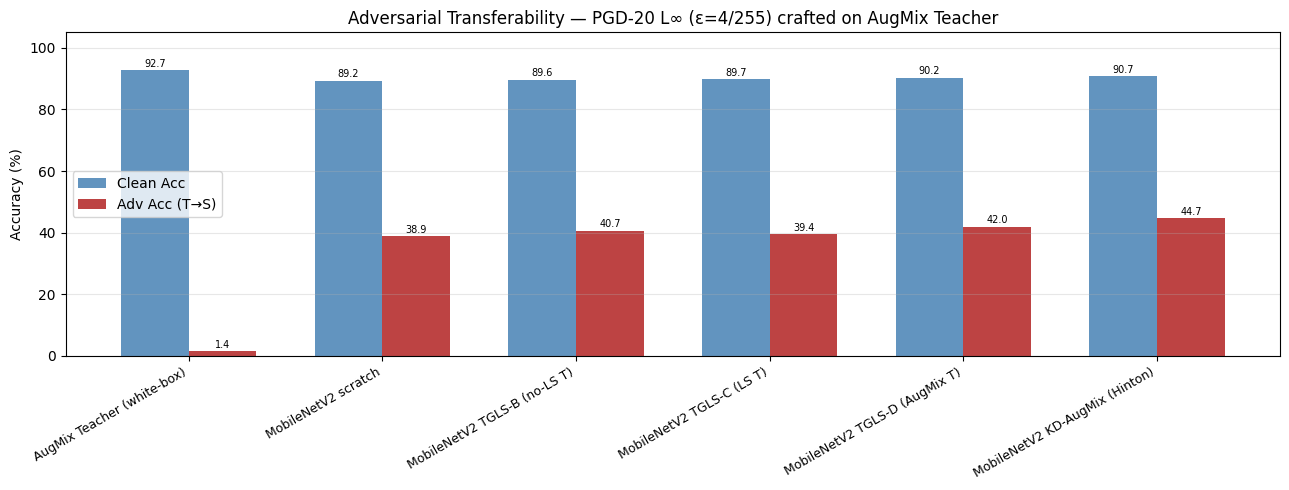

In [6]:
# Bar chart: clean vs adversarial accuracy for each target model
target_names  = [r['Target Model'] for r in transfer_rows]
clean_accs    = [float(r['Clean Acc'].rstrip('%'))     for r in transfer_rows]
adv_accs      = [float(r['Adv Acc (T→S)'].rstrip('%')) for r in transfer_rows]

x = range(len(target_names))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars_clean = ax.bar([i - width/2 for i in x], clean_accs, width, label='Clean Acc',         color='steelblue',  alpha=0.85)
bars_adv   = ax.bar([i + width/2 for i in x], adv_accs,   width, label='Adv Acc (T→S)',    color='firebrick',  alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(target_names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
ax.set_title('Adversarial Transferability — PGD-20 L∞ (ε=4/255) crafted on AugMix Teacher')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, v in zip(bars_clean, clean_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v:.1f}', ha='center', va='bottom', fontsize=7)
for bar, v in zip(bars_adv, adv_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v:.1f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('./outputs/adversarial_transfer_teacher_to_student.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
import torch, sys
sys.path.insert(0, '.')

from models.Transfer import Transfer_Config, build_transfer_model
from pgd_attack import PGD20_LINF, PGD20_L2, evaluate_adversarial
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load Transfer Opt2 ───────────────────────────────────────────────────────
cfg = Transfer_Config(backbone='resnet18', num_classes=10, option=2)
transfer_opt2 = build_transfer_model(cfg)
transfer_opt2.load_state_dict(torch.load('best_transfer_opt2.pth', map_location=DEVICE))
transfer_opt2 = transfer_opt2.to(DEVICE).eval()
print('Transfer Opt2 loaded.')

# ── Test loader ──────────────────────────────────────────────────────────────
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
test_ds = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2)

# ── PGD-20 L-inf and L2 ─────────────────────────────────────────────────────
results_transfer_opt2 = {}
for attack_name, cfg_atk in [('PGD20-Linf', PGD20_LINF), ('PGD20-L2', PGD20_L2)]:
    print(f'\n{"="*60}')
    print(f'Transfer Opt2  |  {attack_name}')
    print(f'{"="*60}')
    results_transfer_opt2[attack_name] = evaluate_adversarial(
        transfer_opt2, test_loader, cfg_atk, DEVICE
    )

# ── Summary ──────────────────────────────────────────────────────────────────
print('\nTransfer Opt2 Adversarial Robustness Summary')
print('=' * 55)
for attack_name, res in results_transfer_opt2.items():
    print(f"  {attack_name:12s} | Clean: {res['clean_acc']*100:.2f}%  "
          f"Adv: {res['adv_acc']*100:.2f}%  "
          f"Fooled: {res['num_fooled']}")
print('=' * 55)


Transfer Opt2 loaded.

Transfer Opt2  |  PGD20-Linf
  Batch   1/79  clean: 0.9531  adv: 0.0078  fooled so far: 121
  Batch   2/79  clean: 0.9570  adv: 0.0078  fooled so far: 243
  Batch   3/79  clean: 0.9505  adv: 0.0078  fooled so far: 362
  Batch   4/79  clean: 0.9512  adv: 0.0059  fooled so far: 484
  Batch   5/79  clean: 0.9578  adv: 0.0047  fooled so far: 610
  Batch   6/79  clean: 0.9505  adv: 0.0039  fooled so far: 727
  Batch   7/79  clean: 0.9442  adv: 0.0033  fooled so far: 843
  Batch   8/79  clean: 0.9414  adv: 0.0029  fooled so far: 961
  Batch   9/79  clean: 0.9418  adv: 0.0026  fooled so far: 1082
  Batch  10/79  clean: 0.9414  adv: 0.0023  fooled so far: 1202
  Batch  11/79  clean: 0.9425  adv: 0.0021  fooled so far: 1324
  Batch  12/79  clean: 0.9414  adv: 0.0020  fooled so far: 1443
  Batch  13/79  clean: 0.9429  adv: 0.0018  fooled so far: 1566
  Batch  14/79  clean: 0.9420  adv: 0.0017  fooled so far: 1685
  Batch  15/79  clean: 0.9411  adv: 0.0021  fooled so far: 1